# STAGE 2 – Task 4: Supervised Learning – Classification Pipeline

**Nhóm 5 – Nhập môn phân tích dữ liệu và A.I**

**Mục tiêu:** Dự đoán một đơn hàng của Pharmacity thuộc nhóm **"Giá trị cao"** hay **"Bình thường"** dựa trên thông tin khách hàng và đơn hàng, sau đó so sánh 2 thuật toán:

- `LogisticRegression()`
- `DecisionTreeClassifier()`

**Các bước thực hiện (theo đúng đề bài):**

1. Đọc dữ liệu & tạo biến mục tiêu (target)
2. Kiểm tra mất cân bằng lớp (class imbalance) và xử lý bằng `class_weight='balanced'`
3. Chuẩn bị đặc trưng & chia Train/Test
4. Huấn luyện 2 mô hình
5. Đánh giá: Confusion Matrix (heatmap) + `classification_report` (Precision, Recall, Accuracy, F1)
6. So sánh & chọn mô hình tốt nhất
7. Xuất model ra file `.pkl` trong thư mục `models/` (để dùng cho Task 5 – Streamlit UI)

## 1. Import thư viện

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

sns.set_style('whitegrid')
RANDOM_STATE = 42   # cố định số ngẫu nhiên để kết quả chạy lại luôn giống nhau

## 2. Đọc dữ liệu

Dùng file `eda_completed_master_dataset.csv` – kết quả sau khi làm sạch ở Stage 1 (1000 đơn hàng, 19 cột).
> Đặt file CSV cùng thư mục với notebook này (hoặc sửa lại đường dẫn bên dưới).

In [2]:
df = pd.read_csv('eda_completed_master_dataset.csv')
print('Kích thước dữ liệu:', df.shape)
df.head()

Kích thước dữ liệu: (1000, 19)


,OrderID,CustomerID,CustomerName,Age,Gender,City,ProductID,Quantity,TotalAmount,PurchaseDate,PaymentMethod,ProductName,Brand,Category,Price,Rating,Source,Currency,Price_VND_ref
0,ORD00001,C0214,Nguyễn Quốc Khoa,37,Nam,Hải Phòng,P10412,3,57000,2026-01-01,Ví điện tử,Bàn chải đánh răng trẻ em từ 2 đến 6 tuổi P/S ...,P/S,Bàn chải đánh răng,19000.0,4.88,Pharmacity_VN,VND,19000.0
1,ORD00002,C0020,Trần Hữu Thành,18,Nam,Đà Nẵng,P18082,3,123000,2026-01-01,Thẻ ngân hàng,Kem Đánh Răng P/S Chăm Sóc Toàn Diện (tuýp 230g),P/S,Kem đánh răng,41000.0,4.92,Pharmacity_VN,VND,41000.0
2,ORD00003,C0144,Bùi Thị Xuân,32,Nữ,TP. Hồ Chí Minh,P29620,1,194250,2026-01-01,Tiền mặt,Kem Đánh Răng Marvis Jasmin Mint Vị Hoa Nhài &...,Marvis,Kem đánh răng,194250.0,4.87,Pharmacity_VN,VND,194250.0
3,ORD00004,C0253,Nguyễn Minh Huy,51,Nam,Hà Nội,P28349,1,110000,2026-01-02,COD,Nước súc miệng SMC Ag+ vệ sinh răng miệng (Cha...,Unknown,Nước súc miệng,110000.0,4.85,Pharmacity_VN,VND,110000.0
4,ORD00005,C0138,Nguyễn Mỹ Dương,27,Nữ,Cần Thơ,P25083,3,37500,2026-01-02,Tiền mặt,Băng vệ sinh ban ngày siêu mỏng cánh Kotex Gar...,Kotex,Băng vệ sinh,12500.0,4.96,Pharmacity_VN,VND,12500.0


## 3. Tạo biến mục tiêu (Target)

Đề bài yêu cầu dự đoán một **nhãn phân loại** (ví dụ Churn/Active). Dataset của nhóm là dữ liệu đơn hàng nên không có sẵn cột Churn, vì vậy nhóm tự tạo nhãn **`High_Value_Order`** từ cột `TotalAmount`:

- `1` = **Đơn giá trị cao**: `TotalAmount` thuộc nhóm **25% cao nhất** (từ phân vị thứ 75 trở lên)
- `0` = **Đơn bình thường**: còn lại

**Ý nghĩa kinh doanh:** nếu biết trước kiểu khách hàng / đơn hàng nào hay có giá trị cao thì Pharmacity có thể tập trung ưu đãi, gợi ý mua thêm (upsell) đúng đối tượng.

### ⚠️ Lưu ý quan trọng: tránh "rò rỉ dữ liệu" (data leakage)
Ta có công thức `TotalAmount = UnitPrice × Quantity`. Nếu đưa `TotalAmount`, `UnitPrice`, `Price`, `Price_VND_ref` vào làm đặc trưng thì mô hình gần như "nhìn thấy đáp án" và điểm số cao một cách giả tạo.
👉 Vì vậy **các cột giá tiền này sẽ bị loại khỏi tập đặc trưng** (chỉ dùng để tạo nhãn).

In [3]:
threshold = df['TotalAmount'].quantile(0.75)
print(f'Ngưỡng đơn giá trị cao (phân vị 75): {threshold:,.0f} VND')

df['High_Value_Order'] = (df['TotalAmount'] >= threshold).astype(int)
df[['TotalAmount', 'High_Value_Order']].head()

Ngưỡng đơn giá trị cao (phân vị 75): 199,000 VND


,TotalAmount,High_Value_Order
0,57000,0
1,123000,0
2,194250,0
3,110000,0
4,37500,0


## 4. Kiểm tra mất cân bằng lớp (Class Imbalance)

Nếu một lớp chiếm quá nhiều, mô hình sẽ "lười" dự đoán toàn bộ là lớp đa số mà vẫn đúng nhiều → **Accuracy cao nhưng vô dụng**. Vì vậy cần đếm số lượng từng lớp trước.

Số lượng từng lớp:
High_Value_Order
0    748
1    252
Name: count, dtype: int64

Tỉ lệ (%):
High_Value_Order
0    74.8
1    25.2
Name: count, dtype: float64


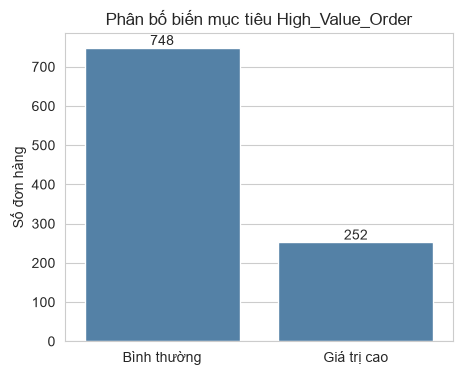

In [4]:
class_names = ['Bình thường', 'Giá trị cao']

counts = df['High_Value_Order'].value_counts().sort_index()
print('Số lượng từng lớp:')
print(counts)
print()
print('Tỉ lệ (%):')
print((counts / len(df) * 100).round(1))

plt.figure(figsize=(5, 4))
ax = sns.countplot(x='High_Value_Order', data=df, color='steelblue')
ax.set_xticks([0, 1])
ax.set_xticklabels(class_names)
ax.bar_label(ax.containers[0])
plt.title('Phân bố biến mục tiêu High_Value_Order')
plt.xlabel('')
plt.ylabel('Số đơn hàng')
plt.show()

**Nhận xét:** tỉ lệ khoảng **75% / 25%** → có **mất cân bằng nhẹ đến vừa**. Lớp "Giá trị cao" ít hơn nhưng lại là lớp doanh nghiệp quan tâm nhất.

**Cách xử lý:** dùng tham số `class_weight='balanced'` – mô hình sẽ tự "phạt nặng hơn" khi đoán sai lớp ít (Giá trị cao). Cách này đơn giản, không cần tạo thêm dữ liệu.

## 5. Chuẩn bị đặc trưng (Features)

**Các đặc trưng được chọn** (đều là thông tin có thể biết/nhập vào khi dự đoán):

| Nhóm | Cột |
|---|---|
| Số | `Age`, `Quantity`, `Rating` |
| Phân loại | `Gender`, `City`, `PaymentMethod`, `Category` |

Cột `Category` có tới 27 giá trị (nhiều loại chỉ có vài đơn) nên nhóm **gộp các loại ngoài Top 10 thành "Khác"** để tránh tạo quá nhiều cột.

Sau đó dùng `pd.get_dummies()` để chuyển các cột chữ thành cột 0/1 (One-Hot Encoding), vì mô hình chỉ hiểu số.

In [5]:
# Gộp Category: giữ Top 10, còn lại gọi là 'Khác'
top_categories = df['Category'].value_counts().head(10).index
df['Category_Group'] = df['Category'].where(df['Category'].isin(top_categories), 'Khác')

feature_cols = ['Age', 'Quantity', 'Rating', 'Gender', 'City', 'PaymentMethod', 'Category_Group']

# One-Hot Encoding (drop_first=True để tránh thừa cột)
X = pd.get_dummies(df[feature_cols],
                   columns=['Gender', 'City', 'PaymentMethod', 'Category_Group'],
                   drop_first=True, dtype=int)
y = df['High_Value_Order']

print('Số đặc trưng sau khi mã hoá:', X.shape[1])
X.head()

Số đặc trưng sau khi mã hoá: 21


,Age,Quantity,Rating,Gender_Nữ,City_Hà Nội,City_Hải Phòng,City_TP. Hồ Chí Minh,City_Đà Nẵng,PaymentMethod_Thẻ ngân hàng,PaymentMethod_Tiền mặt,...,Category_Group_Băng vệ sinh,Category_Group_Dung dịch vệ sinh phụ nữ,Category_Group_Dưỡng thể & massage,Category_Group_Dầu gội đầu,Category_Group_Kem đánh răng,Category_Group_Khác,Category_Group_Khử mùi cho nam,Category_Group_Nước rửa tay,Category_Group_Nước súc miệng,Category_Group_Sữa tắm
0,37,3,4.88,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,18,3,4.92,0,0,0,0,1,1,0,...,0,0,0,0,1,0,0,0,0,0
2,32,1,4.87,1,0,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,0
3,51,1,4.85,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,27,3,4.96,1,0,0,0,0,0,1,...,1,0,0,0,0,0,0,0,0,0


## 6. Chia Train / Test

- 80% dữ liệu để huấn luyện, 20% để kiểm tra.
- `stratify=y` giúp tỉ lệ 75/25 được giữ nguyên ở cả tập Train và Test (rất quan trọng khi dữ liệu mất cân bằng).

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Tỉ lệ lớp "Giá trị cao" ở Train:', round(y_train.mean() * 100, 1), '%')
print('Tỉ lệ lớp "Giá trị cao" ở Test :', round(y_test.mean() * 100, 1), '%')

Train: (800, 21) | Test: (200, 21)
Tỉ lệ lớp "Giá trị cao" ở Train: 25.2 %
Tỉ lệ lớp "Giá trị cao" ở Test : 25.0 %


## 7. Huấn luyện 2 mô hình

### Mô hình 1: Logistic Regression
- Logistic Regression nhạy với thang đo của dữ liệu (ví dụ `Age` ~ 30 nhưng cột 0/1 chỉ là 0 hoặc 1) nên cần **chuẩn hoá bằng `StandardScaler`** trước.
- Dùng `make_pipeline` để gộp 2 bước (chuẩn hoá → mô hình) thành 1 đối tượng, sau này lưu file và dự đoán rất tiện.

Trước tiên, nhóm chạy thử **không dùng** `class_weight` để thấy rõ tác dụng của việc xử lý mất cân bằng.

In [7]:
# (a) Logistic Regression KHÔNG xử lý mất cân bằng - chỉ để so sánh
lr_no_weight = make_pipeline(StandardScaler(),
                             LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
lr_no_weight.fit(X_train, y_train)

# (b) Logistic Regression CÓ class_weight='balanced'
lr_model = make_pipeline(StandardScaler(),
                         LogisticRegression(class_weight='balanced', max_iter=1000,
                                            random_state=RANDOM_STATE))
lr_model.fit(X_train, y_train)

# So sánh tác dụng của class_weight (nhìn vào lớp "Giá trị cao")
for name, m in [('LR không class_weight', lr_no_weight), ('LR có class_weight=balanced', lr_model)]:
    pred = m.predict(X_test)
    print(f'{name:30s} | Recall = {recall_score(y_test, pred):.2f} '
          f'| Precision = {precision_score(y_test, pred):.2f} '
          f'| F1 = {f1_score(y_test, pred):.2f}')

LR không class_weight          | Recall = 0.48 | Precision = 0.65 | F1 = 0.55
LR có class_weight=balanced    | Recall = 0.80 | Precision = 0.49 | F1 = 0.61


**Nhận xét:** khi có `class_weight='balanced'`, **Recall của lớp "Giá trị cao" tăng lên rõ rệt** (mô hình bắt được nhiều đơn giá trị cao hơn), đổi lại Precision giảm. Với bài toán này, bỏ sót đơn giá trị cao tốn kém hơn nên nhóm chọn dùng `class_weight='balanced'`.

### Mô hình 2: Decision Tree
- Cây quyết định **không cần chuẩn hoá** dữ liệu.
- Nếu để cây phát triển tự do, nó sẽ "học thuộc" dữ liệu Train (overfitting). Vì vậy nhóm giới hạn **`max_depth=4`** (cây sâu tối đa 4 tầng) cho đơn giản và dễ giải thích.

In [8]:
dt_model = DecisionTreeClassifier(max_depth=4, class_weight='balanced',
                                  random_state=RANDOM_STATE)
dt_model.fit(X_train, y_train)

print('Đã huấn luyện xong Decision Tree (max_depth=4, class_weight=balanced)')

Đã huấn luyện xong Decision Tree (max_depth=4, class_weight=balanced)


## 8. Đánh giá mô hình

Với mỗi mô hình ta in:
- `classification_report`: Precision, Recall, F1-Score cho từng lớp và Accuracy chung
- **Confusion Matrix** dạng heatmap:
  - Hàng = nhãn thật, cột = nhãn mô hình dự đoán
  - Ô góc trên-trái và dưới-phải là dự đoán **đúng**; hai ô còn lại là dự đoán **sai**

**Cách đọc nhanh:**
- **Precision** (lớp Giá trị cao): trong số đơn mô hình báo "giá trị cao", bao nhiêu % thật sự là giá trị cao?
- **Recall** (lớp Giá trị cao): trong số đơn giá trị cao thật, mô hình tìm ra được bao nhiêu %?
- **F1-Score**: điểm trung bình hài hoà của Precision và Recall.

In [9]:
def evaluate_model(title, model):
    """In classification_report và vẽ heatmap confusion matrix cho một mô hình."""
    y_pred = model.predict(X_test)

    print('=' * 60)
    print(title)
    print('=' * 60)
    print(classification_report(y_test, y_pred, target_names=class_names))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {title}')
    plt.xlabel('Dự đoán')
    plt.ylabel('Thực tế')
    plt.show()
    return y_pred

### 8.1. Logistic Regression

Logistic Regression
              precision    recall  f1-score   support

 Bình thường       0.92      0.72      0.81       150
 Giá trị cao       0.49      0.80      0.61        50

    accuracy                           0.74       200
   macro avg       0.70      0.76      0.71       200
weighted avg       0.81      0.74      0.76       200



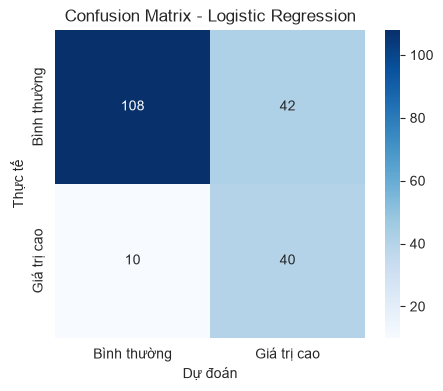

In [10]:
y_pred_lr = evaluate_model('Logistic Regression', lr_model)

### 8.2. Decision Tree

Decision Tree
              precision    recall  f1-score   support

 Bình thường       0.94      0.59      0.72       150
 Giá trị cao       0.42      0.88      0.56        50

    accuracy                           0.66       200
   macro avg       0.68      0.73      0.64       200
weighted avg       0.81      0.66      0.68       200



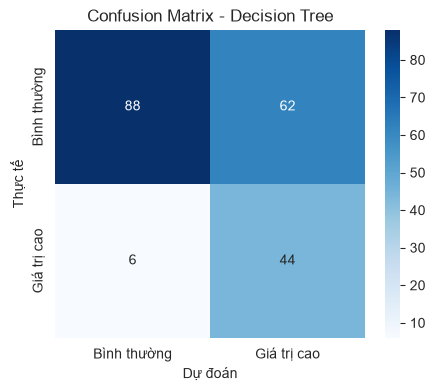

In [11]:
y_pred_dt = evaluate_model('Decision Tree', dt_model)

## 9. So sánh 2 mô hình

Vì dữ liệu mất cân bằng nên **không chọn mô hình chỉ dựa vào Accuracy**. Nhóm dùng **F1-Score của lớp "Giá trị cao"** làm tiêu chí chính (cân bằng giữa Precision và Recall).

Ngoài ra so sánh Accuracy trên tập Train và Test để kiểm tra overfitting (Train cao hơn Test quá nhiều là dấu hiệu xấu).

In [12]:
models = {'Logistic Regression': lr_model, 'Decision Tree': dt_model}

rows = []
for name, m in models.items():
    y_pred = m.predict(X_test)
    rows.append({
        'Mô hình': name,
        'Accuracy (Train)': accuracy_score(y_train, m.predict(X_train)),
        'Accuracy (Test)': accuracy_score(y_test, y_pred),
        'Precision (Giá trị cao)': precision_score(y_test, y_pred),
        'Recall (Giá trị cao)': recall_score(y_test, y_pred),
        'F1 (Giá trị cao)': f1_score(y_test, y_pred),
    })

results = pd.DataFrame(rows).set_index('Mô hình').round(3)
results

,Accuracy (Train),Accuracy (Test),Precision (Giá trị cao),Recall (Giá trị cao),F1 (Giá trị cao)
Mô hình,,,,,
Logistic Regression,0.788,0.74,0.488,0.80,0.606
Decision Tree,0.734,0.66,0.415,0.88,0.564


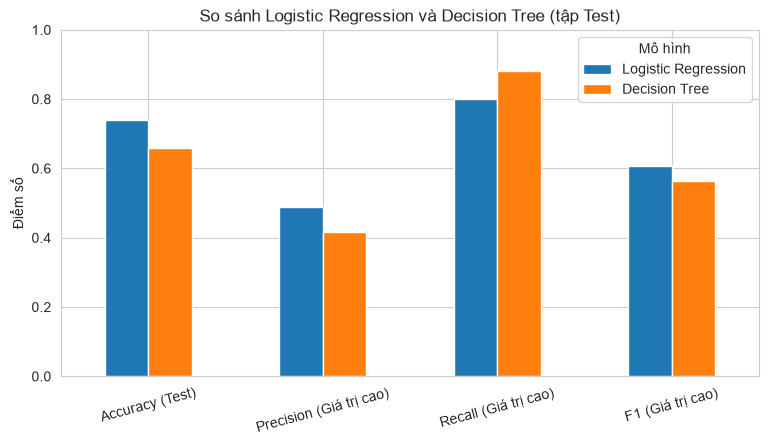

In [13]:
# Biểu đồ cột so sánh các chỉ số trên tập Test
metrics_to_plot = ['Accuracy (Test)', 'Precision (Giá trị cao)', 'Recall (Giá trị cao)', 'F1 (Giá trị cao)']
results[metrics_to_plot].T.plot(kind='bar', figsize=(9, 4.5), rot=15)
plt.title('So sánh Logistic Regression và Decision Tree (tập Test)')
plt.ylabel('Điểm số')
plt.ylim(0, 1)
plt.legend(title='Mô hình')
plt.show()

In [14]:
# Chọn mô hình tốt nhất theo F1 của lớp "Giá trị cao"
best_name = results['F1 (Giá trị cao)'].idxmax()
best_model = models[best_name]

print(f'>>> Mô hình tốt nhất: {best_name}')
print(f'    F1 (Giá trị cao) = {results.loc[best_name, "F1 (Giá trị cao)"]}')
print(f'    Recall           = {results.loc[best_name, "Recall (Giá trị cao)"]}')
print(f'    Precision        = {results.loc[best_name, "Precision (Giá trị cao)"]}')
print(f'    Accuracy (Test)  = {results.loc[best_name, "Accuracy (Test)"]}')

>>> Mô hình tốt nhất: Logistic Regression
    F1 (Giá trị cao) = 0.606
    Recall           = 0.8
    Precision        = 0.488
    Accuracy (Test)  = 0.74


## 10. Yếu tố nào ảnh hưởng đến đơn hàng giá trị cao?

Phần này giúp viết **khuyến nghị kinh doanh** trong báo cáo:
- Logistic Regression: hệ số (coefficient) **dương** → làm tăng khả năng là đơn giá trị cao; **âm** → làm giảm. (Dữ liệu đã chuẩn hoá nên có thể so sánh độ lớn giữa các cột.)
- Decision Tree: `feature_importances_` cho biết cột nào được cây dùng nhiều nhất để chia nhóm.

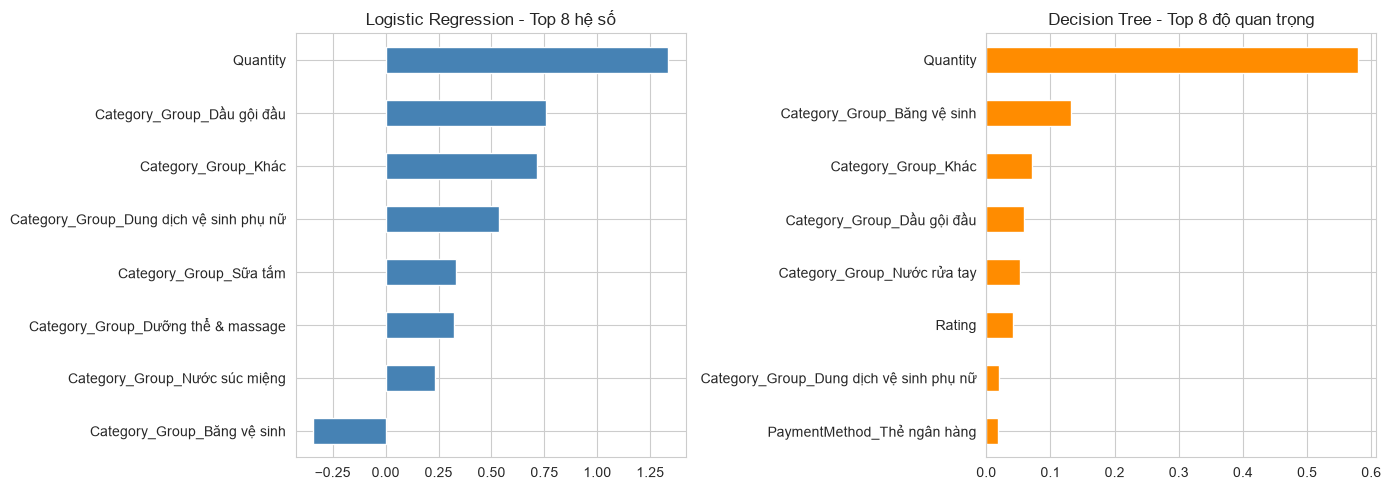

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression: hệ số
coef = pd.Series(lr_model.named_steps['logisticregression'].coef_[0], index=X.columns)
top_coef = coef.reindex(coef.abs().sort_values(ascending=False).head(8).index).sort_values()
top_coef.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Logistic Regression - Top 8 hệ số')

# Decision Tree: độ quan trọng
imp = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(8)
imp.sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Decision Tree - Top 8 độ quan trọng')

plt.tight_layout()
plt.show()

## 11. Kết luận Task 4

*(Nhóm điền nhận xét dựa trên kết quả vừa chạy ở các bảng/biểu đồ phía trên rồi chép vào báo cáo.)*

**Gợi ý các ý cần nêu trong báo cáo:**
1. **Imbalance:** tỉ lệ lớp khoảng 75/25 → dùng `class_weight='balanced'`; nêu rõ Recall lớp "Giá trị cao" tăng bao nhiêu so với khi không dùng.
2. **Mô hình thắng:** nêu tên mô hình có F1 (Giá trị cao) cao nhất ở mục 9 và so sánh Precision/Recall/Accuracy của hai mô hình.
3. **Overfitting:** so sánh Accuracy Train và Test của từng mô hình (đã giới hạn `max_depth=4` để cây không học thuộc).
4. **Hạn chế:** dữ liệu chỉ có 1000 đơn và là dữ liệu mô phỏng giao dịch nên điểm số ở mức vừa phải, không nên kỳ vọng quá cao.
5. **Khuyến nghị kinh doanh:** dựa vào mục 10 (ví dụ: loại sản phẩm và số lượng mua ảnh hưởng mạnh đến giá trị đơn → ưu đãi combo/mua nhiều cho nhóm sản phẩm đó).

## 12. Xuất mô hình để dùng cho Task 5 (Streamlit UI)

Cell cuối cùng sẽ lưu vào thư mục `models/`:
- `classification_model.pkl`: mô hình tốt nhất
- `classification_features.pkl`: danh sách tên cột đặc trưng (khi dự đoán trên UI phải tạo dữ liệu đầu vào **đúng thứ tự cột này**)

Sau đó load lại thử và dự đoán 1 khách hàng mẫu để chắc chắn file `.pkl` hoạt động.

In [16]:
# Tạo thư mục models nếu chưa có
os.makedirs('models', exist_ok=True)

# Lưu mô hình tốt nhất + danh sách cột đặc trưng
joblib.dump(best_model, 'models/classification_model.pkl')
joblib.dump(list(X.columns), 'models/classification_features.pkl')
print(f'Đã lưu mô hình "{best_name}" vào models/classification_model.pkl')
print('Đã lưu danh sách đặc trưng vào models/classification_features.pkl')

# ---- Kiểm tra: load lại file .pkl và dự đoán 1 khách hàng mẫu ----
loaded_model = joblib.load('models/classification_model.pkl')
feature_columns = joblib.load('models/classification_features.pkl')

# Tạo 1 dòng dữ liệu toàn số 0 với đúng các cột, rồi điền thông tin khách hàng
sample = pd.DataFrame(0, index=[0], columns=feature_columns)
sample['Age'] = 30
sample['Quantity'] = 3
sample['Rating'] = 4.8
for col in ['Gender_Nữ', 'City_Hà Nội', 'PaymentMethod_Ví điện tử', 'Category_Group_Dầu gội đầu']:
    if col in sample.columns:
        sample[col] = 1

pred = loaded_model.predict(sample)[0]
proba = loaded_model.predict_proba(sample)[0][1]
print()
print('Khách hàng mẫu -> dự đoán:', class_names[pred])
print(f'Xác suất là đơn giá trị cao: {proba:.1%}')

Đã lưu mô hình "Logistic Regression" vào models/classification_model.pkl
Đã lưu danh sách đặc trưng vào models/classification_features.pkl

Khách hàng mẫu -> dự đoán: Giá trị cao
Xác suất là đơn giá trị cao: 92.7%
